In [6]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

In [7]:
url = "https://news.ycombinator.com/"
response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [8]:
soup = BeautifulSoup(response.text, "html.parser")

In [9]:
titles = soup.find_all("span", class_="titleline")

headline_list = []
link_list = []

for t in titles:
    a_tag = t.find("a")
    headline_list.append(a_tag.text)
    link_list.append(a_tag['href'])

# Preview
headline_list[:5]

["GitHub's Fake Star Economy",
 'M 7.4 earthquake – 100 km ENE of Miyako, Japan',
 "NSA is using Anthropic's Mythos despite blacklist",
 'Up to 8M Bees Are Living in an Underground Network Beneath This Cemetery',
 'Focused microwaves allow 3D printers to fuse circuits onto almost anything']

In [10]:
df = pd.DataFrame({
    "Headline": headline_list,
    "Link": link_list
})

df.head()

,Headline,Link
0,GitHub's Fake Star Economy,https://awesomeagents.ai/news/github-fake-star...
1,"M 7.4 earthquake – 100 km ENE of Miyako, Japan",https://earthquake.usgs.gov/earthquakes/eventp...
2,NSA is using Anthropic's Mythos despite blacklist,https://www.reuters.com/business/us-security-a...
3,Up to 8M Bees Are Living in an Underground Net...,https://www.discovermagazine.com/up-to-8-milli...
4,Focused microwaves allow 3D printers to fuse c...,https://newatlas.com/electronics/meta-nfc-focu...


In [12]:
df.to_csv("news_headlines.csv", index=False)

In [13]:
all_text = " ".join(headline_list)

In [14]:
words = all_text.lower().split()

In [16]:
stopwords = ['the', 'is', 'and', 'to', 'of', 'in', 'for', 'on', 'with', 'a', 'an']

filtered_words = [word for word in words if word not in stopwords]

In [17]:
word_count = Counter(filtered_words)
common_words = word_count.most_common(10)

common_words

[('claude', 3),
 ('i', 3),
 ('–', 2),
 ('are', 2),
 ('beneath', 2),
 ('system', 2),
 ('listening', 2),
 ('swiss', 2),
 ("github's", 1),
 ('fake', 1)]

In [18]:
df_words = pd.DataFrame(common_words, columns=["Word", "Count"])

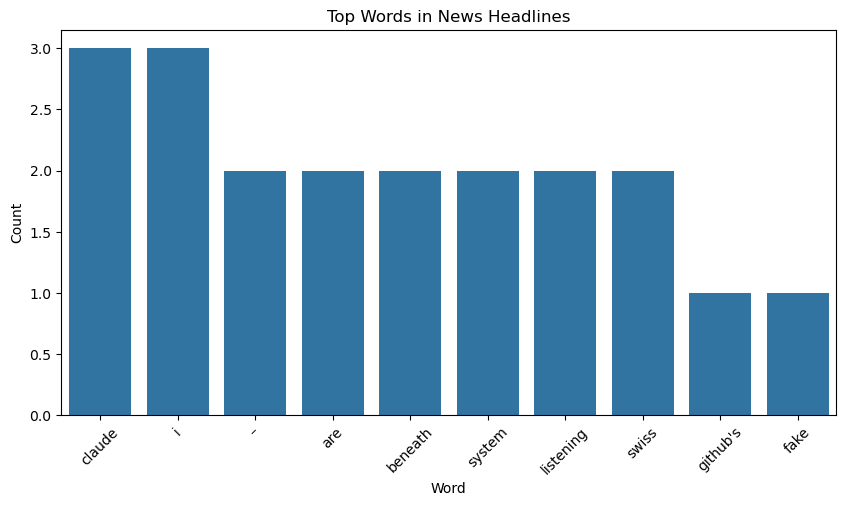

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(x="Word", y="Count", data=df_words)

plt.title("Top Words in News Headlines")
plt.xticks(rotation=45)
plt.show()